# 1. Which residues can carry a dye?

A FRET experiment starts with a mutation, and the mutation is the part you
cannot take back: a dye on the wrong residue reports on the dye, not on the
protein. The *label score* (Dimura et al., Nat. Commun. 11, 5394, 2020) ranks
every residue of a structure by how well it would tolerate one, out of terms
that are each a likelihood ratio: how exposed the residue is, whether it looks
like a cysteine already, what secondary structure it sits in, how close the
nearest tryptophan is (a quencher), the local charge, and how conserved it is.

The terms **multiply**. That matters here, and it is the first thing this
notebook has to deal with.

We work on BmrA, a homodimeric ABC transporter, in its two known states.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

import IMP.bff as bff
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd()))
import workshop as ws

print("build:", bff.get_build(), "| version:", bff.get_module_version())
structures = {state: ws.single_dimer(state) for state in ("closed", "open")}
for state, path in structures.items():
    print(f"{state:7s} {ws.STATES[state]['pdb_id']}  {ws.STATES[state]['note']}")

build: imp | version: ab5de21
closed  6R72  outward-facing, E504A, ATP/Mg (X-ray)
open    8QOE  inward-facing (cryo-EM)


## The conservation term, and why it is switched off here

The published model carries a conservation term at weight 1. Conservation is
not computed from the structure -- it comes from a multiple alignment, as
ConSurf grades, and it has to exist for the protein in front of you.

For BmrA it does not. UniProt O06967 carries no per-residue conservation
track, ConSurf-DB had no entry reachable, and labelizer.org returns a
header-only table for both entries. (Checked 2026-09-07; the detail is in
`prototypes/bmra/bmra/conservation.py`.)

Because the terms multiply, running the paper model unchanged with no grades
does not give you "the score without conservation" -- it gives you **zero for
every residue**. The notebook shows that, and then drops the term.

In [2]:
paper = bff.labelizer_model_paper()
print("paper model:", [(p.tag, p.weight, p.table or "-") for p in paper])

scores = bff.labelizer_score_structure(str(structures["closed"]), paper,
                                       bff.LabelizerOptions(), "")
combined = [s.value for s in scores if s.score_type == "combined"]
print(f"\nwith the paper model and no grades: {len(combined)} residues, "
      f"every score = {np.nanmax(combined):.2f}")

paper model: [('cs', 1, 'N_CS2_Score'), ('se', 1, 'N_SE11_MEAN_SURFACE_DIST'), ('tp', 0, '-'), ('cr', 1, 'C_CR1_Name'), ('ss', 1, 'C_SS1_SS'), ('ce', 0, '-')]



with the paper model and no grades: 1140 residues, every score = 0.00


In [3]:
model = bff.LabelizerParameterList()
for parameter in paper:
    if parameter.tag != "cs":
        model.append(parameter)
print("model used here:", [(p.tag, p.weight) for p in model])


def label_scores(pdb_path):
    """{(chain, residue): combined score} for one structure."""
    rows = bff.labelizer_score_structure(str(pdb_path), model,
                                         bff.LabelizerOptions(), "")
    return {(r.asym_id, r.seq_id): r.value
            for r in rows if r.score_type == "combined"}


ls = {state: label_scores(path) for state, path in structures.items()}
for state, table in ls.items():
    values = np.array([v for v in table.values() if np.isfinite(v)])
    print(f"{state:7s} {len(table):5d} residues, score {values.min():.2f}-{values.max():.2f}, "
          f"mean {values.mean():.2f}")

model used here: [('se', 1), ('tp', 0), ('cr', 1), ('ss', 1), ('ce', 0)]


closed   1140 residues, score 0.00-1.90, mean 1.04


open     1136 residues, score 0.00-2.07, mean 0.94


## The protomers must agree

BmrA is a homodimer: chains A and B are the same sequence in (nearly) the same
fold. The label score is a property of one protomer, so the two chains should
score the same residue alike. They do -- which is a free check that the
structure was cut correctly and that the score is reading what we think it is.
A site where the two disagree is a site where the two protomers really differ
in that structure, and it is worth knowing before you mutate it.

## One number is four numbers

The combined score is the **weighted geometric mean** of the terms, so reading
it alone throws away the reason for it. Two sites can score the same because
one is beautifully exposed and barely cysteine-like, and the other the other
way round -- and those two sites behave differently when you put a dye on them.

`labelizer_score_structure` returns every term, not just the combination: one
row per (residue, score type). Here they are for the same structure.

In [4]:
def components(pdb_path):
    """{(chain, residue): {score type: value}} -- every term, not just the total."""
    rows = bff.labelizer_score_structure(str(pdb_path), model,
                                         bff.LabelizerOptions(), "")
    table = {}
    for row in rows:
        table.setdefault((row.asym_id, row.seq_id), {})[row.score_type] = row.value
    return table


parts = {state: components(path) for state, path in structures.items()}
TERMS = ["solvent_exposure", "cysteine_resemblance", "secondary_structure",
         "charge_environment", "tryptophan_proximity"]
weights = {p.tag: p.weight for p in model}
print("term weights in this model:",
      {"se": weights["se"], "cr": weights["cr"], "ss": weights["ss"],
       "ce": weights["ce"], "tp": weights["tp"]})

site = parts["closed"][("A", 428)]
for term in TERMS + ["combined"]:
    print(f"  {term:24s} {site[term]:6.3f}")

term weights in this model: {'se': 1, 'cr': 1, 'ss': 1, 'ce': 0, 'tp': 0}
  solvent_exposure          1.978
  cysteine_resemblance      2.185
  secondary_structure       1.362
  charge_environment        0.545
  tryptophan_proximity      1.000
  combined                  1.805


### The combination, checked

Weight 1 on solvent exposure, cysteine resemblance and secondary structure;
weight 0 on charge environment and tryptophan proximity, so those two are
computed and reported but do not enter. The geometric mean of the three that
count reproduces the combined score exactly -- which is also why a single term
at zero takes the whole site to zero, as the conservation term did above.

In [5]:
used = [("solvent_exposure", "se"), ("cysteine_resemblance", "cr"),
        ("secondary_structure", "ss")]

print(f"{'site':>6} {'se':>7} {'cr':>7} {'ss':>7} {'geo.mean':>9} {'combined':>9}")
for resi in (428, 436, 19, 223):
    values = parts["closed"][("A", resi)]
    product = np.prod([values[term] for term, _ in used])
    geometric = product ** (1.0 / len(used))
    print(f"{'A' + str(resi):>6} " + " ".join(f"{values[t]:7.3f}" for t, _ in used)
          + f" {geometric:9.3f} {values['combined']:9.3f}")

  site      se      cr      ss  geo.mean  combined
  A428   1.978   2.185   1.362     1.805     1.805
  A436   1.326   3.864   1.330     1.896     1.896
   A19   0.601   0.567   0.981     0.694     0.694
  A223   1.978   1.205   0.981     1.327     1.327


### Every term along the sequence

The terms disagree, and where they disagree is where the choice is actually
made. Solvent exposure is the one that moves most between the two states --
it is a property of the surface, and the surface is what the transition
changes. Cysteine resemblance and secondary structure are properties of the
sequence and the fold, so they barely move.

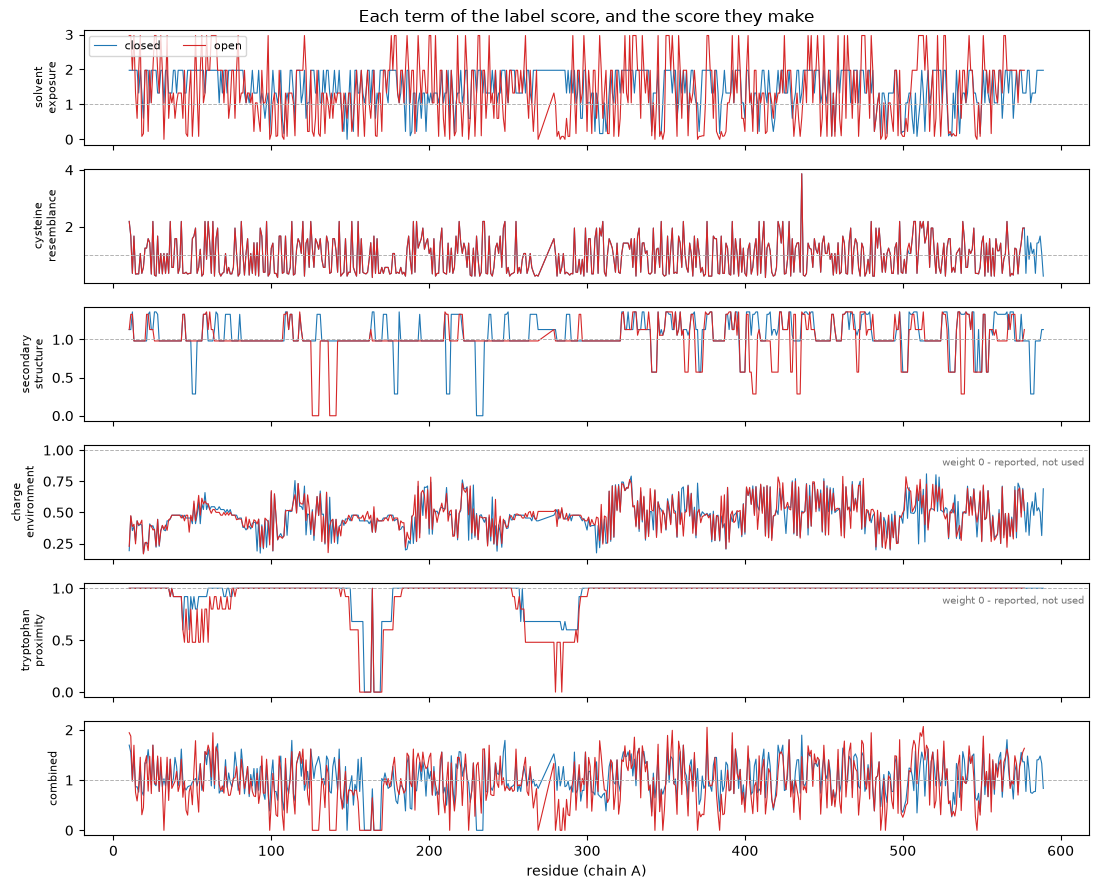

In [6]:
fig, axes = plt.subplots(len(TERMS) + 1, 1, figsize=(11, 9), sharex=True)
residues = sorted(r for (c, r) in parts["closed"] if c == "A")

for ax, term in zip(axes, TERMS + ["combined"]):
    for state, colour in (("closed", "C0"), ("open", "C3")):
        values = [parts[state].get(("A", r), {}).get(term, np.nan) for r in residues]
        ax.plot(residues, values, lw=0.8, color=colour,
                label=state if term == TERMS[0] else None)
    weight = 1 if term == "combined" else weights[{"solvent_exposure": "se",
        "cysteine_resemblance": "cr", "secondary_structure": "ss",
        "charge_environment": "ce", "tryptophan_proximity": "tp"}[term]]
    ax.axhline(1.0, color="0.7", lw=0.7, ls="--")
    ax.set_ylabel(term.replace("_", "\n"), fontsize=8)
    ax.text(0.995, 0.82, "weight 0 - reported, not used" if weight == 0 else "",
            transform=ax.transAxes, ha="right", fontsize=7.5, color="0.45")
axes[0].legend(fontsize=8, ncol=2, loc="upper left")
axes[-1].set_xlabel("residue (chain A)")
axes[0].set_title("Each term of the label score, and the score they make")
fig.tight_layout()
plt.show()

### What the terms are computed from

Underneath the likelihood ratios are plain structural quantities, and it is
worth seeing them once: the secondary structure assignment, how buried the
residue is, and how much of its surface is reachable. A site chosen against
the score is a site chosen against these.

DSSP: -=138, B=28, E=44, G=18, H=598, I=10, S=128, T=176
residue depth 1.61 - 4.22 A
relative solvent accessibility 0.00 - 0.92


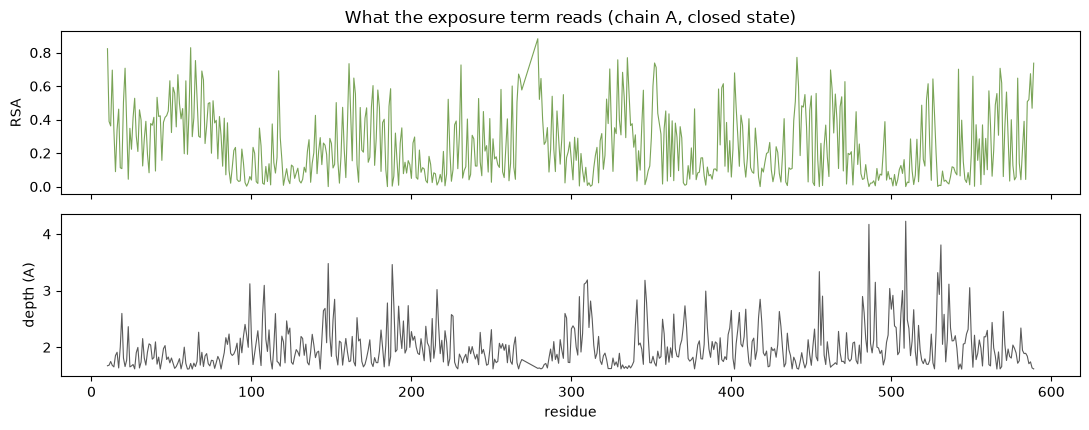

In [7]:
structure = bff.labelizer_read_structure(str(structures["closed"]))
secondary = bff.labelizer_dssp(structure)
depth = np.asarray(bff.labelizer_residue_depth(structure, 1.4, 590))
rsa = np.asarray(bff.labelizer_relative_solvent_accessibility(
    structure, bff.LABELIZER_MAXASA_WILKE, 1.4, 590))

counts = {s: secondary.count(s) for s in sorted(set(secondary))}
print("DSSP:", ", ".join(f"{k or '-'}={v}" for k, v in counts.items()))
print(f"residue depth {depth.min():.2f} - {depth.max():.2f} A")
print(f"relative solvent accessibility {rsa.min():.2f} - {rsa.max():.2f}")

chain_a = [i for i, r in enumerate(structure.residues) if r.chain == "A"]
seq_a = [structure.residues[i].seq_id for i in chain_a]

fig, (ax, bx) = plt.subplots(2, 1, figsize=(11, 4.4), sharex=True)
ax.plot(seq_a, rsa[chain_a], lw=0.8, color="#7aa457")
ax.set_ylabel("RSA")
ax.set_title("What the exposure term reads (chain A, closed state)")
bx.plot(seq_a, depth[chain_a], lw=0.8, color="#5a5a5a")
bx.set_ylabel("depth (A)"); bx.set_xlabel("residue")
fig.tight_layout()
plt.show()

### Which term decided

For each candidate, the term furthest from 1 is the one that made the
decision -- above 1 it argued for the site, below 1 against. A site carried by
a single strong term is a more fragile choice than one every term likes.

In [8]:
top_by_score = sorted(
    ((values["combined"], resi) for (chain, resi), values in parts["closed"].items()
     if chain == "A" and np.isfinite(values["combined"])),
    reverse=True)[:10]

print(f"{'site':>6} {'combined':>8}  {'strongest for':>30}  {'strongest against':>30}")
for score, resi in top_by_score:
    values = parts["closed"][("A", resi)]
    scored = {term: values[term] for term, _ in used}
    best = max(scored, key=lambda t: scored[t])
    worst = min(scored, key=lambda t: scored[t])
    print(f"{'A' + str(resi):>6} {score:8.2f}  "
          f"{best + f' {scored[best]:.2f}':>30}  {worst + f' {scored[worst]:.2f}':>30}")


  site combined                   strongest for               strongest against
  A436     1.90       cysteine_resemblance 3.86           solvent_exposure 1.33
  A566     1.81       cysteine_resemblance 2.19        secondary_structure 1.36
  A428     1.81       cysteine_resemblance 2.19        secondary_structure 1.36
  A376     1.79       cysteine_resemblance 2.19        secondary_structure 1.33
  A248     1.79       cysteine_resemblance 2.19        secondary_structure 1.33
  A113     1.79       cysteine_resemblance 2.19        secondary_structure 1.33
   A66     1.72           solvent_exposure 1.98        secondary_structure 1.33
  A424     1.70       cysteine_resemblance 2.19        secondary_structure 1.13
  A421     1.70       cysteine_resemblance 2.19        secondary_structure 1.13
  A392     1.70       cysteine_resemblance 2.19        secondary_structure 1.13


In [9]:
closed = ls["closed"]
shared = sorted({r for (c, r) in closed if (("A", r) in closed and ("B", r) in closed)})
a = np.array([closed[("A", r)] for r in shared])
b = np.array([closed[("B", r)] for r in shared])
good = np.isfinite(a) & np.isfinite(b)
print(f"{good.sum()} residues in both protomers")
print(f"largest A-B difference: {np.abs(a[good] - b[good]).max():.3f}")
print(f"mean |A-B|:             {np.abs(a[good] - b[good]).mean():.3f}")

565 residues in both protomers
largest A-B difference: 1.416
mean |A-B|:             0.088


## The score along the sequence

The useful sites are the peaks: exposed, unstructured enough, no tryptophan
next door. The two states mostly agree -- the label score is about the local
environment, and most of the protein does not change between them -- but not
everywhere, and a site that is good in one state and buried in the other is a
site that will behave differently depending on what the molecule is doing.

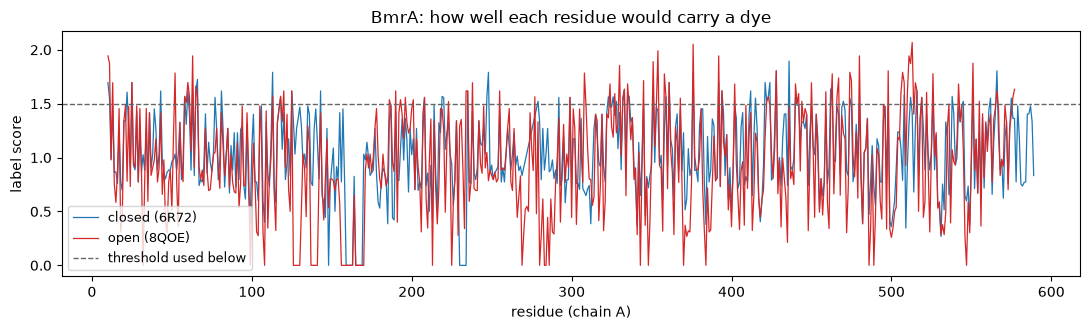

In [10]:
fig, ax = plt.subplots(figsize=(11, 3.4))
for state, colour in (("closed", "C0"), ("open", "C3")):
    table = ls[state]
    residues = sorted(r for (c, r) in table if c == "A")
    values = [table[("A", r)] for r in residues]
    ax.plot(residues, values, lw=0.9, color=colour, label=f"{state} ({ws.STATES[state]['pdb_id']})")
ax.axhline(1.5, color="0.4", ls="--", lw=1, label="threshold used below")
ax.set_xlabel("residue (chain A)"); ax.set_ylabel("label score")
ax.set_title("BmrA: how well each residue would carry a dye")
ax.legend(fontsize=9); fig.tight_layout()
plt.show()


## Candidate sites

A candidate has to clear the threshold **in both states** -- a site that is
only labelable in one of them cannot report on the change between them -- and
candidates too close together in sequence are redundant, because they see the
same neighbourhood. What comes out is the shortlist the next notebooks work
with.

In [11]:
THRESHOLD, MIN_SEPARATION = 1.5, 10

def candidates(threshold=THRESHOLD, min_separation=MIN_SEPARATION):
    both = []
    for (chain, resi), value in ls["closed"].items():
        if chain != "A" or not np.isfinite(value) or value < threshold:
            continue
        other = ls["open"].get(("A", resi), np.nan)
        if np.isfinite(other) and other >= threshold:
            both.append((resi, min(value, other)))
    both.sort(key=lambda row: -row[1])
    chosen = []
    for resi, value in both:
        if all(abs(resi - taken) >= min_separation for taken, _ in chosen):
            chosen.append((resi, value))
    return chosen


sites = candidates()
print(f"{len(sites)} candidate sites (score >= {THRESHOLD} in both states, "
      f">= {MIN_SEPARATION} residues apart)\n")
print(f"{'residue':>8} {'closed':>7} {'open':>7}")
for resi, _ in sites[:15]:
    print(f"{resi:>8} {ls['closed'][('A', resi)]:>7.2f} {ls['open'][('A', resi)]:>7.2f}")

21 candidate sites (score >= 1.5 in both states, >= 10 residues apart)

 residue  closed    open
     428    1.81    1.81
     376    1.79    2.05
      10    1.70    1.94
      25    1.70    1.70
     361    1.70    1.70
     392    1.70    1.94
     351    1.65    1.89
     551    1.64    1.88
     333    1.63    1.63
      65    1.62    1.66
     125    1.62    1.62
     235    1.62    1.62
     516    1.62    1.62
     566    1.81    1.62
     113    1.79    1.57


## What a candidate looks like

The score is a number about a neighbourhood, so it is worth looking at the
neighbourhood. Below, the two best candidates are shown on the closed dimer as
the accessible volume a dye would occupy there -- which is also the subject of
notebook 3. If the Mol* view does not appear, it needs internet access from
the browser; nothing else in the notebook depends on it.

In [12]:
top = [resi for resi, _ in sites[:2]]
print("showing sites", top)

panel = ws.site_panel(
    "closed",
    [{"chain": "A", "resi": top[0], "colour": ws.DONOR_COLOUR},
     {"chain": "B", "resi": top[0], "dye": "Alexa647", "colour": ws.ACCEPTOR_COLOUR}],
    title=f"BmrA closed - site {top[0]} on both protomers",
)
ws.show([panel])

showing sites [428, 376]


### The score on the fold

The same numbers, painted onto the structure: blue is a poor site, red a good
one. This is the picture worth taking into the lab -- the good sites are on
the outside of the helices and in the loops, and the whole nucleotide-binding
interface is blue because a dye there has nowhere to sit.

The score goes into the B-factor column, which is how any viewer can colour
by it; `score_coloured_pdb` writes that file and Mol*'s uncertainty theme
reads it.


In [13]:
panels = []
for state in ("closed", "open"):
    combined = {key: values["combined"] for key, values in parts[state].items()}
    panels.append({
        "title": f"BmrA {state} - coloured by label score (blue poor, red good)",
        "structure": ws.score_coloured_pdb(structures[state], combined),
        "colour_by": "score",
        "clouds": [],
    })
ws.show(panels, height=460)


## Next

Notebook 3 turns a site into a *volume* and a pair of sites into a distance.
The homodimer question -- which **sites** to mutate, given that one mutation
labels both protomers and every pair it implies comes for free -- is
`../../ipynb/example/labelizer_greedy_homodimer.ipynb`.